In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as spo
import astropy.io.fits as fits  # get FITS 

### 0. 

- Spectroscopy: see lectures 11/12 and 14
- N-body simulations: a whole universe to cover, not easy to do so in one lecture :-/ You can check an example code out [here](https://github.com/BetaGem/N-body-galaxy) and the paper [here](https://arxiv.org/abs/1412.5187), or another code [here](https://github.com/elkogerville/MSG_Nbody)

### 1. VPN and cluster connections

- get [VPN](https://ucf.service-now.com/ucfit?id=kb_article&sysparm_article=KB0010298&sys_kb_id=ff89f4764f45e200be64f0318110c763&spa=1) set up 

- if you are ON CAMPUS connect with WPA2
- if you are NOT on campus connect to campus with VPN

- Start your MobaXterm or terminal and you can connect to Stokes
    - remember to use your NID (not PID)
    
    
- A list of commands to communicate with Stokes can be found in the week_2/Unix_command_line_101 pdf
    - most important remember the scp:
        - scp -r <what> <to where>:
            - e.g., scp -r my_hw_folder myNID@stokes.ist.ucf.edu:'ast4762c/homework/' $\rightarrow$to copy from my laptop to stokes, in location ast4762c/homework/
            - scp -r myNID@stokes.ist.ucf.edu:'ast4762c/homework/mytarfile.tar.gz' . $\rightarrow$ to copy the tar file from location ast4762c/homework/ wherever I am with the terminal in my laptop (.)
   

### 2. Reading FITS headers and data

#### FITS: the Flexible Image Transport System

In [2]:
# we will use an image we have seen a few times
file_to_read= 'examplecleanimage2.fits'

In [3]:
#how do we get the data?
image = fits.getdata( file_to_read )


In [4]:
image.shape

(2068, 2100)

In [5]:
#how do we get the header?

#way 1:
headr_1 = fits.getheader( file_to_read)

print(headr_1['GAIN'])

1.74


In [6]:
#way 2:
# we can do it in one go when we get the data too:
image, headr_2 = fits.getdata( file_to_read, header=True)


In [57]:
print(headr_2['GAIN'])

1.74


### 3. Error propagation



<div class="alert alert-block alert-warning">
<b> Error Propagation Equation:
$$\sigma_{f}^{2} \simeq  \sigma_{x}^{2} (\frac{\partial{f}}{\partial{x}})^{2}
                         + \sigma_{y}^{2} (\frac{\partial{f}}{\partial{y}})^{2}
                         + ...
                         + 2\sigma_{xy}^{2}
                            \frac{\partial f}{\partial x}
                            \frac{\partial f}{\partial y}
                         + ...$$
 

    
- If $u$ and $v$ are uncorrelated (one’s not positive when the other is, and vice versa), then ($u_i - \bar u)(v_i - \bar v)$ will be negative half the time and positive half the time, and the sum will tend to zero. So, for uncorrelated variables, we can drop the co-variance terms. In that case our eq. simplifies to:


<div class="alert alert-block alert-warning">
<b> Error Propagation Equation w/o correlation:
    
$$\sigma_{f}^{2} \simeq  \sigma_{x}^{2} (\frac{\partial{f}}{\partial{x}})^{2}
                         + \sigma_{y}^{2} (\frac{\partial{f}}{\partial{y}})^{2}
                         +....$$

### 
- note that in some cases the result from this one can coincide with the results you get from the relative errors you use, but in other cases there is a considerable divergence


#### What you need to remember:

- find the partial derivatives $\frac{\partial f}{\partial x_i}$ over all independent quantities $x_i$
- multiply each one with the error in that quantity $\sigma_{x_i}$
- square and add
- use square root:

- Error to report = $\sqrt{ ( \sigma_{x} \frac{\partial{f}}{\partial{x}})^{2}
                         + ( \sigma_{y}(\frac{\partial{f}}{\partial{y}})^{2}} $

In [177]:
# function f(x) = 3 x**2

x = 2.0
dx = 0.3
fx = 3* x**2




#partial derivative over x:
par_x = 3* 2* x

#error of fx:
dfx = dx * par_x #note that the sqrt() and **2 cancel out

print('{0:.1f}+-{1:.1f}'.format(fx, dfx) )

12.0+-3.6


In [178]:
# function f(x,y) = 2*x + y**2



y  = 1.0
dy = 0.1

fx2 = 2*x + y**2

#partial derivative over x:
par_x2 = 2
#partial over y:
par_y2 = 2* y

#error of fx2:
dfx2 = np.sqrt( (dx * par_x2)**2 + (dy * par_y2) )

print('{0:.1f}+-{1:.1f}'.format(fx2, dfx2) )

5.0+-0.7


In [179]:
#function f(x,y) = log10( 2*x) + 3* y**2

fx3 = np.log10( 2* x ) + 3* y**2




par_x3 = 2/ (2 * x * np.log( 10 ) )
par_y3 = 6 * y

#error of fx2:
dfx3 = np.sqrt( (dx * par_x3)**2 + (dy * par_y3) )

print('{0:.1f}+-{1:.1f}'.format(fx3, dfx3) )

3.6+-0.8


### 4. Fitting of data 

### Assume you have this dataset 

<img src="least_sq_data1.png" width=350 height=250 />

### and you know that a model should follow an equation of the form: $ y = a*x +b $ but, how do you find the best-fit model? 

### One way would be to try different models, use different a and b parameters and see which one fits the data best right? Let’s try different models of this form:

<img src="least_sq_data2.png" width=350 height=250 />

### which one is the best? 

### We need a way to quantify what "best-fit" model means. 

#### ---> minimize the sum of the squares of the offsets ("the residuals") of the points from the curve; normalized 


### $R^2 = \Sigma_i  \frac{(O_i - E_i )^2}{E_i}$ 

#### where, $O_i$ is our data and $E_i$ the expected model points. The smaller $R^2$  is, the better the  model fits the data!

<img src="least_sq_data3.png" width=350 height=250 />

### So far we ignored that our data can have an error bar. Assuming that the data/measurements are independent of each other and that they are normally distributed, if we have N independent variables $y_i$ with mean $\mu_i$ and variance $\sigma^2_i$, we can define $\chi^2$ as :

### $\chi^2$ = $\Sigma \frac{(y_i - \mu_i)^2}{\sigma^2_i}$

### Note that the error we fit is in the y dimension; we assume that the mean x position is accurate. If $y$ data follow a gaussian (i.e., normal) distribution this process is the chi-square minimization and is the same as least squares fitting – if not you do a least squares ---- the premise of the $\chi^2$ test is that the deviations from the model are due to statistical fluctuations due to our limited numbers of observations per bin, i.e. we deal with "noise" or Poisson statistics

#### Important to remember are the  degrees of freedom (dof) : 

$n = N_{data-points} – N_{fitted-parameters}$

#### for calculating the reduced $\chi^2$ you want $\chi^2 / n < 1 $

### Generalized form :

 $$\chi ^2 = \Sigma w_i  (y_i - f_i)^2 $$

#### where weight $w_i$ can be:

- $\frac{1}{\sigma_i^2}$ 

- $\frac{1}{f_i}$ 

#### If observations are correlated we need to calculate the ‘covariance matrix’


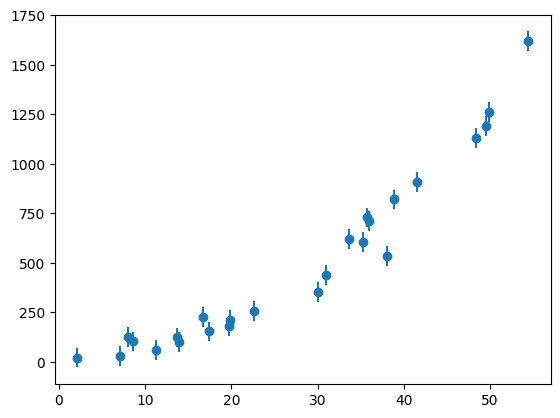

In [7]:
#let's try it out on this dataset:

prob5_data = np.loadtxt( 'puzzle5.dat' )
x5 = prob5_data[ :, 0 ]
y5 = prob5_data[ :, 1 ]

#plot the data
inds = np.argsort ( x5 )

ynew = y5[ inds ]
xnew = x5[ inds ]

dm = plt.errorbar(xnew,ynew,  marker = 'o',yerr = 50 , linestyle ='')


### we can go about it 2 ways:
- Manual way (the grid case)
    - see also example in Bad pixels ICA and Fitting_data_practicum.ipynb for comparing against grid of models
- Taking advantage of scipy (leastsq, curvefit etc)


$\rightarrow$ you don't know which funct your data follows? try different distributions and compare 


### the grid path:
1. define the parameter space you want to scan
2. for each and every possible combination make a model
3. compare it against the data/obs and calculate and store the $\chi^2$ value
4. find the minimum $\rightarrow$ bestfit model

In [8]:
# 0.5* c* t**2 + b *t + a
#71.86163260355988 -5.269861463286427 1.174459735185295

#let's try to fit model with:
a = np.arange( 65, 75, 0.01)
b = np.arange( -5.5, -3.5, 0.01)
c = np.arange( .9, 1.3, 0.1)

#make the 3D cube where we will store the chis for all possible combis of a,b,c
chis = np.zeros( ( len(a), len(b), len(c) ))

for i in range( len( a ) ):
    for j in range( len( b ) ):
        for k in range( len( c ) ):
            #calculate the model for this combi:
            model = a[ i ] + b[ j ] * xnew + 0.5* c[ k ] * xnew**2
            
            #calculate its difference from the obs:
            chis[ i, j, k] = np.sum( ( (ynew - model)**2 / 50**2 ) )


4

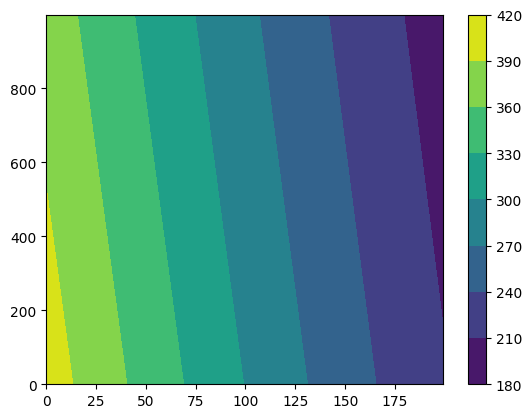

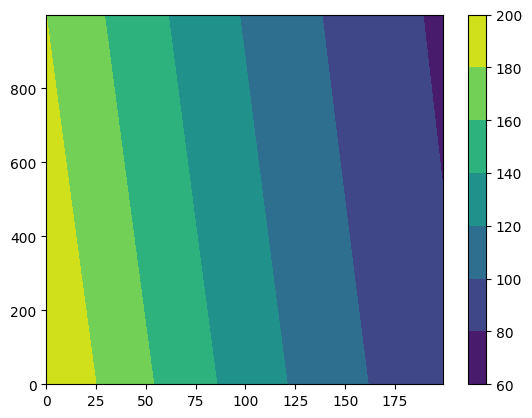

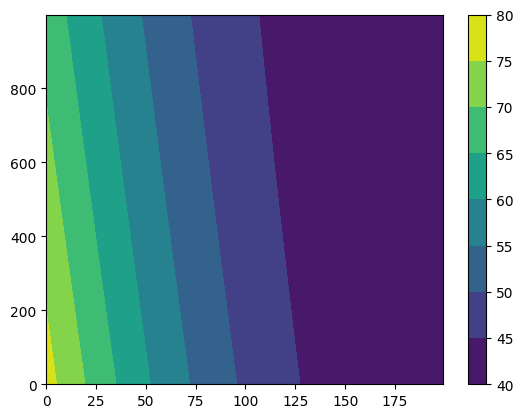

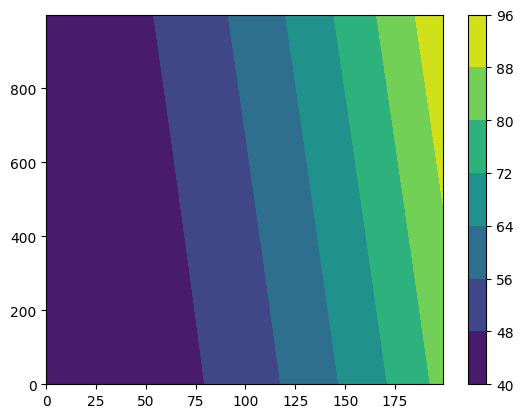

In [9]:
plt.contourf(  np.arange(len(b)), np.arange(len(a)), chis[ :, :, 0])
plt.colorbar()
plt.show()
plt.contourf(  np.arange(len(b)), np.arange(len(a)), chis[ :, :, 1])
plt.colorbar()
plt.show()
plt.contourf(  np.arange(len(b)), np.arange(len(a)), chis[ :, :, 2])
plt.colorbar()
plt.show()
plt.contourf(  np.arange(len(b)), np.arange(len(a)), chis[ :, :, 3])
plt.colorbar()
plt.show()

In [10]:
#find where the minimum is:
best_fit = np.where( chis == np.min( chis) )


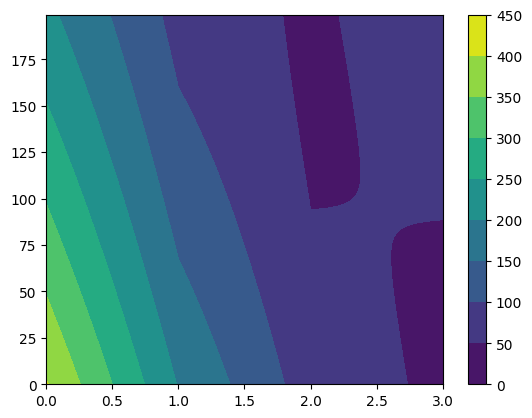

In [11]:
plt.contourf(  np.arange(len(c)), np.arange(len(b)), chis[ best_fit[ 0 ][0], : , :])
plt.colorbar()
plt.show()

In [12]:
#print the best-solution:
print("The best fit is y={0:.2f} + {1:.2f}*t +0.5*{2:.2f}*t$^2$".format(
a[ best_fit[ 0 ][0] ], b[ best_fit[ 1 ][0]], c[ best_fit[2]][0] ))

The best fit is y=65.73 + -5.50*t +0.5*1.20*t$^2$


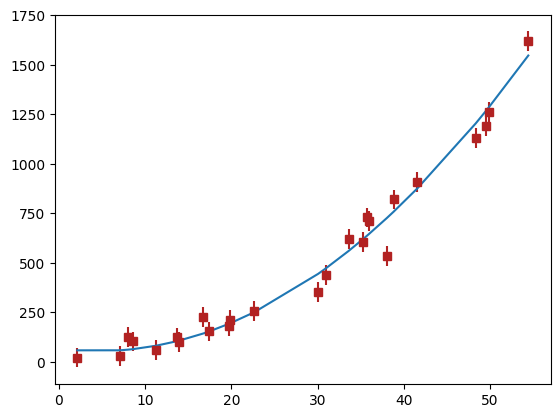

In [13]:
plt.errorbar(xnew, ynew, yerr= np.ones(len(x5))*50, color='firebrick', marker = 's' , linestyle = 'none')
dm = plt.plot(xnew,  a[ best_fit[ 0 ][0] ]+ b[ best_fit[ 1 ][0]]* xnew + 0.5 * c[ best_fit[2]][0] * xnew**2)

#### The leastsq path:
1. define a function that you want to fit 
2. define a function that calls funct 1 and calculates the residuals with the data
3. call leastq()

Status: 1
Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Reduced chi-squared:1.8091e+00
Results and uncertainties:
[[71.86160813 34.60672123]
 [-5.26985939  2.83699045]
 [ 1.17445967  0.09803132]]
Covariance matrix:
[[ 1.19762515e+03 -8.84737214e+01  2.71471340e+00]
 [-8.84737214e+01  8.04851479e+00 -2.70354275e-01]
 [ 2.71471340e+00 -2.70354275e-01  9.61013934e-03]]
# function evals: 9


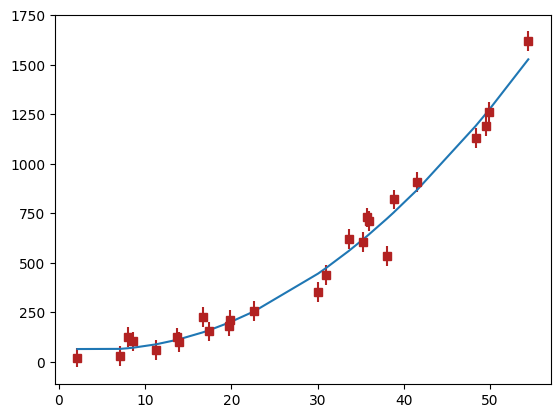

In [14]:
#use leatsq fit to fit the data with model 2:

#define your function to be fit:
def gendata(t, par):
#    print( par[0], par[1], par[2])
    return 0.5* par[ 2 ]* t**2 + par[ 1 ] *t + par[ 0 ]

#make initial guess c, b, a
par = np.array([60., .4,.2])

#define redisuals function
def residuals(par):
    return (gendata(xnew, par) - ynew)/50

#call scipy optimize:
(fit2, cov_x, infodict, mesg, ier) = spo.leastsq(residuals, par, full_output=True)
fiterr2 = np.sqrt(np.diag(cov_x))

# check status FIRST!
print("Status: {0:d}".format(ier)) # 1 = solution found
print(mesg)
print("Reduced chi-squared:{0:.4e}".format(np.sum(residuals(fit2)**2) / (len(xnew) - fit2.size))) # reduced chi-squared
print("Results and uncertainties:")
print(np.array((fit2, fiterr2)).T) # ok, now the results
print("Covariance matrix:")
print(cov_x)  # and errors, including covariance terms
print("# function evals: {0:d}".format(infodict['nfev']))

plt.errorbar(xnew, ynew, yerr= np.ones(len(x5))*50, color='firebrick', marker = 's' , linestyle = 'none')
dm = plt.plot(xnew, gendata(xnew, fit2) )
# dummy=0



#### The curvefit path:

1. Define a function that you want to fit
2. Call curvefit

In [17]:
def trycurvefit(t, a, b, c):
    return a + b * t + 0.5 * c * t**2 

(fit2, cov_x, infodict, mesg, ier) = spo.curve_fit( trycurvefit, xnew ,ynew, 
                       full_output = True, sigma = np.repeat(50, len(xnew)), absolute_sigma=True)

Status: 1
Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Reduced chi-squared:6.9467e-12
Results and uncertainties:
[[71.861614   34.60672195]
 [-5.26985996  2.83699047]
 [ 1.17445969  0.09803132]]
Covariance matrix:
[[ 1.19762520e+03 -8.84737246e+01  2.71471345e+00]
 [-8.84737246e+01  8.04851493e+00 -2.70354275e-01]
 [ 2.71471345e+00 -2.70354275e-01  9.61013920e-03]]
# function evals: 9


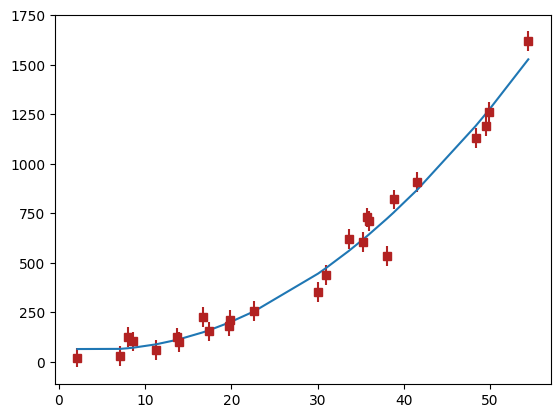

In [18]:
# check status FIRST!
fiterr = np.sqrt(np.diag(cov_x))

print("Status: {0:d}".format(ier)) # 1 = solution found
print(mesg)
print("Reduced chi-squared:{0:.4e}".format(np.sum(trycurvefit(xnew,*fit2) - ynew)**2 / (len(xnew) - fit2.size))) # reduced chi-squared
print("Results and uncertainties:")
print(np.array((fit2, fiterr)).T) # ok, now the results
print("Covariance matrix:")
print(cov_x)  # and errors, including covariance terms
print("# function evals: {0:d}".format(infodict['nfev']))

plt.errorbar(xnew, ynew, yerr= np.ones(len(x5))*50, color='firebrick', marker = 's' , linestyle = 'none')
#dm = plt.plot(xnew, gendata(xnew, fit2) )
dm = plt.plot(xnew, trycurvefit(xnew, *fit2) )


#### if you don't know what func your data should follow you try different funcs and compare:

Status: 1
Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000
Reduced chi-squared:7.9710e+00
Results and uncertainties:
[[-259.90481566   20.75478865]
 [  27.77026498    0.66547479]]
Covariance matrix:
[[430.76125196 -12.10288532]
 [-12.10288532   0.44285669]]
# function evals: 7
Speed: 27.770264983429925


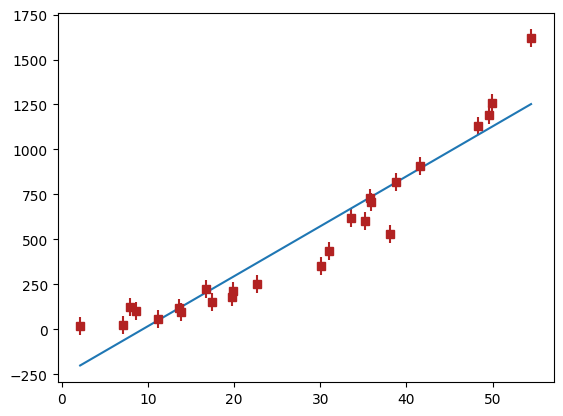

In [19]:
#use leatsq fit to fit the data with linear case:

#define your function to be fit:
def gendata(t, par):
    return par[ 1 ] *t + par[ 0 ]

#make initial guess c, b, a
par = np.array([8., 3.])

#define redisuals function
def residuals(par):
    return (gendata(xnew, par) - ynew)/50

#call scipy optimize:
(fit, cov_x, infodict, mesg, ier) = spo.leastsq(residuals, par, full_output=True)
fiterr = np.sqrt(np.diag(cov_x))

# check status FIRST!
print("Status: {0:d}".format(ier)) # 1 = solution found
print(mesg)
print("Reduced chi-squared:{0:.4e}".format(np.sum(residuals(fit)**2) / (len(xnew) - fit.size))) # reduced chi-squared
print("Results and uncertainties:")
print(np.array((fit, fiterr)).T) # ok, now the results
print("Covariance matrix:")
print(cov_x)  # and errors, including covariance terms
print("# function evals: {0:d}".format(infodict['nfev']))

plt.errorbar(xnew, ynew, yerr= np.ones(len(xnew))*50, color='firebrick', marker = 's' , linestyle = 'none')
plt.plot(xnew, gendata(xnew, fit) )
# dummy=0

print( 'Speed:',fit[1] )

### VERY important: how do i quantify 2nd fit is better than 1st and thus the 2nd is the right model?
- compare $\chi$s: 7.9710e+00 vs  1.8091e+00

### Let's look a bit at the covariance matrix:

|    |    |     |
|:-----:|:---:|:-----:|
| 1.19762537e+03 | -8.84737420e+01 | 2.71471413e+00 |
|-8.84737420e+01 | 8.04851663e+00 |-2.70354338e-01|
|  2.71471413e+00| -2.70354338e-01|  9.61014143e-03|

### is of the form
|    |    |     |
|:-----:|:---:|:-----:|
| $\frac{\partial y^2}{\partial a^2}$ |  $\frac{\partial y^2}{\partial a \partial b}$ | $\frac{\partial y^2}{\partial a \partial c}$   |
| $\frac{\partial y^2}{\partial b \partial a}$ |  $\frac{\partial y^2}{\partial b^2}$ | $\frac{\partial y^2}{\partial b \partial c}$   |
| $\frac{\partial y^2}{\partial c \partial a}$ |  $\frac{\partial y^2}{\partial c \partial b}$ | $\frac{\partial y^2}{\partial c^2}$   |


- note that there is non-zero covariance for ab, ac, bc which makes sense (why?) 

- Also, remember that $$\sigma_{f}^{2} \simeq  \sigma_{u}^{2} ( \frac{\partial f}{\partial u})^{2}
                         + \sigma_{v}^{2} ( \frac{\partial f}{\partial v})^{2}
                         + ...
                         + 2\sigma_{uv}^{2}
                            \frac{\partial f}{\partial u}
                            \frac{\partial f}{\partial v}
                         + ...$$


In [20]:
#we can use the info from the covariance matrix to do our error propagation 
#so we want to calculate the error of y, e.g. in x =34

#use error propagation for y = 0.5 * a * x**2 + b * x + c

# dy/da = a * x 
# dy/db = b 
# dy/dc = 1

# from covariance matrix:
# sigma_a^2 = cov[ 0,0 ]
# sigma_b^2 = cov[ 1,1 ]
# sigma_c^2 = cov[ 2,2 ]
# with co-variances:
# sigma_ab = cov[ 0,1 ]
# sigma_ac = cov[ 0,2 ]
# sigma_bc = cov[ 1,2 ]

#[[71.8616326  34.60672435]
# [-5.26986146  2.83699077]
# [ 1.17445974  0.09803133]]

#1.19762537e+03 -8.84737420e+01  2.71471413e+00]
# [-8.84737420e+01  8.04851663e+00 -2.70354338e-01]
# [ 2.71471413e+00 -2.70354338e-01  9.61014143e-03]] 

x1 = 34 

yloc = 0.5 * 1.174459741 * x1 **2 -5.26986146 * x1 + 71.8616326 
dyloc = np.sqrt( 
              ( 1.174459741 * x1)**2 * 1.19762537e+03 +  #(a * x)**2 * sigma_a**2
              ( -5.26986146 )**2 * 8.04851663e+00  +    #b**2 * sigma_b**2
                9.61014143e-03 +                       # sigma_c**2
            #now do the covariance parts:
             2* ( 1.17445974 * x1**2  * (-8.84737420e+01) ) +  # a * x* x  * sigma_ab
             2* (  1.17445974 * x1 * 2.71471413e+00)      +    # a * x * 1 * sigma_ac
             2* (x1 *(-2.70354338e-01) )                  # x * 1 * sigma_bc
            )

print( 'y+-dy is: {0:.2f}+-{1:.2f}'.format(yloc,dyloc))

y+-dy is: 571.52+-1292.22


### 5. Combining frames 
- As you will be reminded in 6, we need to make a few (10 or more) frames for all the frames we need for photometry
- With the exception of the science frames the rest of them we use to make a master frame
    - median combination
    <img src="image_combination.png" width=500> 
    
    <img src="ica_biases_yf.png" width=300> 

In [21]:
#example like we saw before:

np.random.seed(18)
dark1 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark2 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark3 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark4 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )  
dark5 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )
dark6 = np.reshape( np.random.normal(loc=4.0, scale=1.0, size=250*250) , (250,250) )

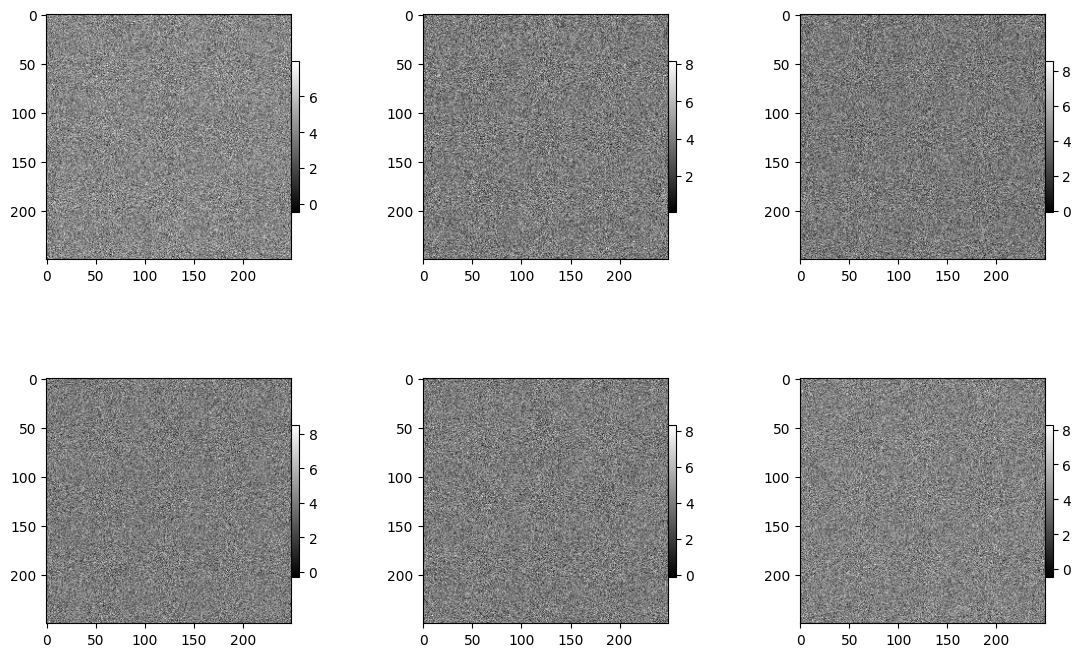

In [22]:
#let's see them all:

fig,( (ax1,ax2, ax3), (ax4,ax5,ax6) ) = plt.subplots( 2, 3, figsize = (12, 8) )
im1 = ax1.imshow( dark1,cmap= 'gray' )
fig.colorbar(im1, ax=ax1,fraction=0.03, pad=0.0)
im2 = ax2.imshow( dark2,cmap= 'gray' )
fig.colorbar(im2, ax=ax2,fraction=0.03, pad=0.0)
im3 = ax3.imshow( dark3,cmap= 'gray' )
fig.colorbar(im3, ax=ax3,fraction=0.03, pad=0.0)
im4 = ax4.imshow( dark4,cmap= 'gray' )
fig.colorbar(im4, ax=ax4,fraction=0.03, pad=0.0)
im5 = ax5.imshow( dark5,cmap= 'gray' )
fig.colorbar(im5, ax=ax5,fraction=0.03, pad=0.0)
im6 = ax6.imshow( dark6,cmap= 'gray' )
fig.colorbar(im6, ax=ax6,fraction=0.03, pad=0.0)
fig.tight_layout(pad=5.0)

In [23]:
#we want to stack them up, so we make the 3D cube:

#find the size of the cube:

nx, ny = dark1.shape
dark_cube = np.zeros( ( 6, nx, ny ) )

In [24]:
#now we will populate the cube:
frame_names=[ dark1, dark2, dark3, dark4, dark5, dark6]

for i in range( 6 ):
    dark_cube[ i ] = frame_names[ i ]

In [25]:
dark_cube.shape

(6, 250, 250)

In [26]:
#do median combi:
med_dark = np.median( dark_cube, axis = 0 )

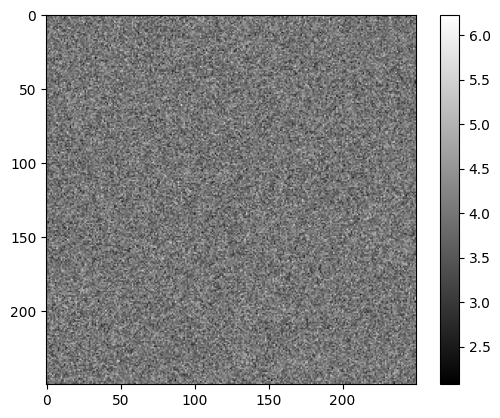

In [27]:
plt.imshow( med_dark,cmap= 'gray' )
dm = plt.colorbar()

### 6. Photometry recap from basis

- Plan your observations correctly:
    - understand your detector (check out documentation!)
    - take bias frames
        - take observations w/o exposure to light (shutter closed), for $t_\mathrm{int}$=0.000 seconds.
        - best to work with an average or median frame composed of many (10 or more) individual bias images
        - Producing a histogram of a typical averaged bias frame gives Gaussian distribution
            - the mean level of this distribution gives the bias level offset for the CCD
            - width is related to the read noise of the CCD $$\rm{FWHM} = \frac{\rm{read_{-}noise}}{\mathrm{Gain}}$$
    - take flats
        - For imaging applications: obtain a flat field image by illuminating the inside of the telescope dome (or a screen mounted on the inside of the dome) with a light source $\rightarrow$ point the telescope at the bright spot on the dome 
        - take few relatively short exposures so as not to saturate the CCD $\rightarrow$ average to get master flat field
        - repeat for every filter you want to use
        - can also have sky flats (twilight or night sky)
        
        
    - in all cases, make many images; use **median combination** of your data cubes to get the **master** frame
    - take science frames 
    
    
</br>    
    
- You got your images cleaded up. Now it's time for photometry!
    1. Centering: 
        - Need to know exact (sub-pixel) center of PSF for photometry. Many methods exist:
            - fit a gaussian yourself (see class'es gaussian.py)
            - use astropy's centroid_2dg
            - use astropy's centroid_com $\rightarrow$ tends to do a bit better for stars
            
    2. Make radial profile to figure out how big your masks shouls be and
    3. Make your masks (remember to clean bad pixels too)
            - use disk.py or astropy's [Apertures](https://photutils.readthedocs.io/en/stable/user_guide/aperture.html)
    4. Count the flux in the masks and their sizes in pixels
        - Use aperture photometry equation:$$F_{*,{\rm cal}} =   F_{*,{\rm raw}}- N_{*}\frac{F_{\rm sky}}{N_{\rm sky}} = F_{*,{\rm raw}} - N_{*} \bar{F_{sky}}$$

        - Or, subtract mean sky from image, then sum aperture (same thing)
        
            


In [45]:
# we will use an image we have seen a few times

example_1 = fits.getdata('examplecleanimage2.fits')
xref = 752
yref = 1291

extra_sky_pxl = 40
cleanimg = example_1[0:2048,19:2067]

photom = cleanimg[yref-extra_sky_pxl:yref+extra_sky_pxl, 
                      xref-extra_sky_pxl:xref+extra_sky_pxl]

xcen1, ycen1 = centroid_com( photom ) 

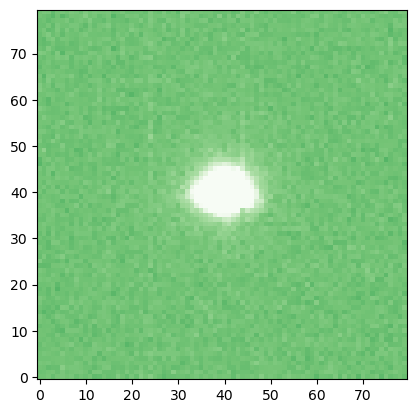

In [46]:
qm = np.median( photom)
qs = np.std( photom )

dm = plt.imshow( photom, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')


In [66]:
import gaussian as g
import radprof as R
import disk as d

import matplotlib.patches as pat


  wy          wx            cy           cx           height
[1.36277186 1.7857519 ] [40.1484375  40.12625583] 11967.477867913687
[5.82425148e-05 7.63191516e-05 5.82427564e-05 7.63191518e-05
 5.11466499e-01]


Text(0.5, 1.0, 'Radial Profile')

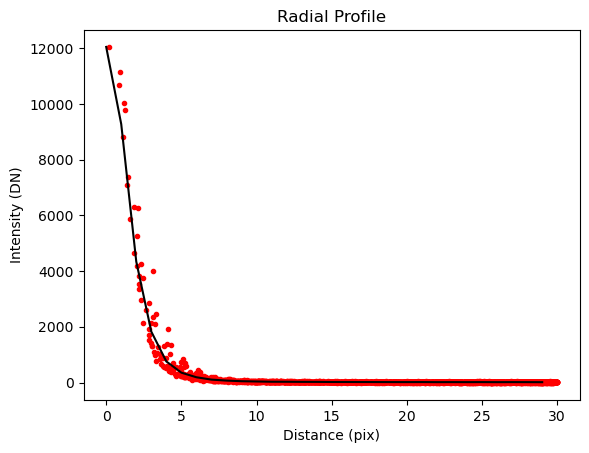

In [80]:
#first we will do this with our class' material (gaussian, radprof, disk):

guess = ((3, 3), (39, 40), photom.max())
(fw, fc, fh, fe) = g.fitgaussian(photom - np.median(photom), guess=guess)
print("  wy          wx            cy           cx           height")
print(fw, fc, fh)
print(fe)

# look at radial profile
(bins, rp, sr, sim) = R.radprof(photom, fc[0], fc[1])
frp = 3
plt.figure(frp)
plt.clf()
pbin = 30
incl = np.where(sr <= pbin)[0]
plt.plot(sr[incl], sim[incl], '.r')
plt.plot(bins[0:pbin], rp[0:pbin], '-k')
plt.xlabel('Distance (pix)')
plt.ylabel('Intensity (DN)')
plt.title('Radial Profile')

In [81]:
print('The location of the center is (cy,cx) = ({0:.3f}, {1:.3f}))'.format(fc[0],fc[1]))
print('The gaussian width is (wy, wx) = ({0:.3f}, {1:.3f}))'.format(fw[0],fw[1]))
print('and we want to use 3-4 times this for the apperture')

The location of the center is (cy,cx) = (40.148, 40.126))
The gaussian width is (wy, wx) = (1.363, 1.786))
and we want to use 3-4 times this for the apperture


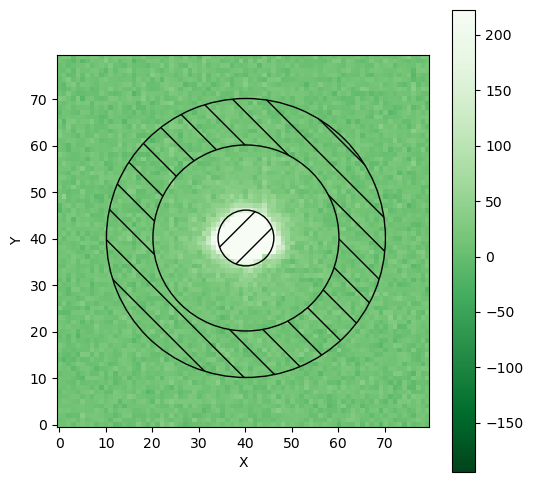

In [82]:
# Set aperture, sky inner and outer radii
aprad  = 6.
skyin  = 20.
skyout = 30.

# Make masks
apmask  =   d.disk(aprad,  fc, photom.shape)
skymask =   d.disk(skyout, fc, photom.shape) \
          ^ d.disk(skyin,  fc, photom.shape)

#let's visualize them on the image:
plt.figure( figsize = (6,6))
plt.imshow( photom, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')
    #if im2d.dtype != bool:  # colorbar breaks on bool due to deprecated math
plt.colorbar()
plt.xlabel("X")
plt.ylabel("Y")
    
ax2 = plt.gca()
appat = pat.Circle(fc[::-1], aprad, fc="none", hatch='/', color="black")
ax2.add_artist(appat)
skypat = pat.Wedge(fc[::-1], skyout, 0, 360,
                   fc="none", width=skyout-skyin, hatch='\\', color="black")
dm = ax2.add_artist(skypat)


In [76]:
#now we go on to counting!

#1. count the number of pixels in aperture and disk:
n_ap  = np.sum(apmask)
n_dsk = np.sum(skymask)

In [85]:
print('Size for aperture and disk are ')
print('--------------------------------------')
print( n_ap, '      ', n_dsk)

Size for aperture and disk are 
--------------------------------------
113        1572


In [77]:
#count the number DNs in both aperture and disk:
f_ap  = np.sum( apmask * photom )
f_dsk = np.sum( skymask* photom )

In [84]:
print('Pure counts for aperture and disk are ')
print('--------------------------------------')
print( f_ap, '      ', f_dsk)

Pure counts for aperture and disk are 
--------------------------------------
200116.81        21132.676


In [78]:
#normalize the f_dsk to find the average DNs per pixel in the sky:

nrm_dsk = f_dsk / n_dsk


In [90]:
print('Normalized sky bckg per pixel:', nrm_dsk)

Normalized sky bckg per pixel: 13.443177977894402


In [79]:
#now count how many real counts we have in the aperture, corrected for the 
#background noise by multiplying the number of pixels in the aperture with the average
#noise we know there is per pixel:

Nstar_norm = f_ap - n_ap * nrm_dsk

print( Nstar_norm)

198597.73338849793


In [167]:
#let's see how to do things with astropy

from photutils import CircularAperture, CircularAnnulus, aperture_photometry
#from photutils.aperture import ApertureStats #--> if you have the newest photutils you can use this for std
from photutils.centroids import centroid_com

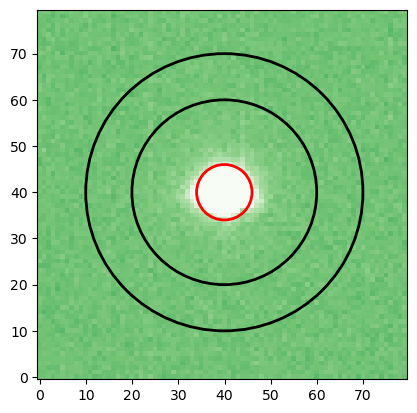

In [47]:
# we set the aperture radius for the photometry
aperture_radius = 6.0

positions = (xcen1, ycen1)

#call the circular aperture funct
apertures = CircularAperture(positions, r=aperture_radius)

#we set the sky annulus ('donut')
r_in = 20
r_out = 30

#call the circular annulus funct
annulus_apertures = CircularAnnulus(positions, r_in=r_in, r_out=r_out)


#let's overplot them to see what astropy does
qm = np.median( photom)
qs = np.std( photom )

dm = plt.imshow( photom, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')

apertures.plot(color='red', lw=2)
dm =annulus_apertures.plot(color='black', lw=2, alpha=1)


In [48]:
#get the counts
photometry_1 = aperture_photometry( photom , [apertures, annulus_apertures])
print(photometry_1)

 id      xcenter           ycenter        aperture_sum_0     aperture_sum_1  
           pix               pix                                             
--- ----------------- ----------------- ------------------ ------------------
  1 39.94327626847322 39.98278717444643 200102.04718686285 21017.160802501803


In [49]:
#compare apert_sum_0 with star counts: 200116.81         from previous step
#and apert_sum_1 with star area dark counts: 21132.676  from prev. step

In [88]:
#get the background normalized:

# get the pixel counts to see and compare:
print('Pixel counts here are:' , apertures.area, annulus_apertures.area)
#compare with 113 and 1572 from prev notebook

skynorm = photometry_1['aperture_sum_1'] / annulus_apertures.area

print('Normalized sky bckg per pixel:', skynorm) #compare with 13.4431779 from prev step

Pixel counts here are: 113.09733552923255 1570.7963267948965
Normalized sky bckg per pixel:   aperture_sum_1  
------------------
13.379940125901552


In [91]:
print( 'Corrected photometry for star here is:', photometry_1['aperture_sum_0'] - apertures.area *skynorm)
#
#compare with: 198597.73 from before

Corrected photometry for star here is:   aperture_sum_0 
-----------------
198588.8116090827


In [144]:
#make a fake bias:
biasdata = np.reshape( np.random.normal(loc=1.0, scale=1.0, 
                                        size=len(photom)**2) , photom.shape )

#do the photometry in the bias
photometry_bias = aperture_photometry( biasdata , annulus_apertures)
#print(photometry_bias['aperture_sum'])

In [171]:
n_read = 2 


n_sky  = ( (photometry_1['aperture_sum_1'] - photometry_bias['aperture_sum'])/
         np.sum(annulus_apertures.area) ) * headr_1['GAIN']
#assume a 10 bias counts:
n_dark =  ( ( photometry_bias['aperture_sum']- 10)/annulus_apertures.area ) * headr_1['GAIN']

n_star  = photometry_1['aperture_sum_0'] - apertures.area *skynorm * headr_1['GAIN']

In [172]:
print( n_sky, n_dark, n_star)

  aperture_sum_1  
------------------
21.546121989438188    aperture_sum   
------------------
1.7238966455913196   aperture_sum_0  
------------------
197469.01728152542


In [173]:
snr = n_star/ np.sqrt( n_sky + n_dark + n_read + n_star ) 

In [174]:
print( snr )

  aperture_sum_0  
------------------
444.34643072299923


In [175]:
#notice that a quick comparison of the sums gives a drastically different snr:
print( photometry_1['aperture_sum_0']/ photometry_1['aperture_sum_1'])

  aperture_sum_0 
-----------------
9.520888623692857


In [176]:
#but, if we do the appropriate corrections we get a closer value 
print( (photometry_1['aperture_sum_0'] - apertures.area *skynorm)/ 
      np.sqrt( (photometry_1['aperture_sum_0'] - apertures.area *skynorm) + 
              apertures.area * np.std( photom[skymask] )**2  ) #note here that the np.std is used 
                                                               #because I have an older photutil; with new
                                                               #you can use ApertureStats ->aperstats.std
     )


  aperture_sum_0 
-----------------
434.8182538542268
